# 🧹 Minería de Datos — Semana 5
## Notebook de Ejercitación: Preprocesamiento de Datos

**Tecnicatura en Informática — Politécnico Malvinas Argentinas — 2026**

---

### 📋 Actividad de foro

> **Instrucciones:** Completá las celdas marcadas con `# TODO` y subí tu notebook
> resuelto al foro de la semana. La participación en el foro es **requisito**
> para acceder a la evaluación parcial.

**Nombre:** Alderete Tomás  
**Fecha de entrega:** 20/05/2026

---

### Objetivos

- Detectar y tratar valores faltantes con distintas estrategias
- Detectar y tratar outliers con winsorización y transformación logarítmica
- Aplicar normalización (MinMax) y estandarización (Standard, Robust)
- Codificar variables categóricas con Label Encoding y One-Hot Encoding
- Construir un pipeline de preprocesamiento completo con scikit-learn

### Dataset
Usamos el **Titanic** (que ya conocemos) y el dataset **Housing** de California
(nuevo — para practicar con más variedad).

---
## 📦 Setup — importar librerías y cargar datasets

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, RobustScaler,
    LabelEncoder, OneHotEncoder, OrdinalEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

plt.rcParams['figure.figsize'] = (12, 4)
sns.set_theme(style='whitegrid', palette='Set2')

print('Setup completo ✓')

Setup completo ✓


In [ ]:
# ── Dataset 1: Titanic ──────────────────────────────────────────────────
url_titanic = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(url_titanic)

# ── Dataset 2: California Housing ───────────────────────────────────────
# Dataset de precios de viviendas con valores faltantes y outliers reales
from sklearn.datasets import fetch_california_housing
housing_data = fetch_california_housing(as_frame=True)
housing = housing_data.frame.copy()
housing.columns = [c.lower() for c in housing.columns]

# Introducir nulos artificialmente para practicar (como en la realidad)
rng = np.random.default_rng(42)
idx_nulos = rng.choice(housing.index, size=500, replace=False)
housing.loc[idx_nulos[:300], 'total_bedrooms'] = np.nan
housing.loc[idx_nulos[300:], 'population']     = np.nan

print(f'Titanic:  {titanic.shape}')
print(f'Housing:  {housing.shape}')



Titanic:  (891, 12)
Housing:  (20640, 10)


In [ ]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


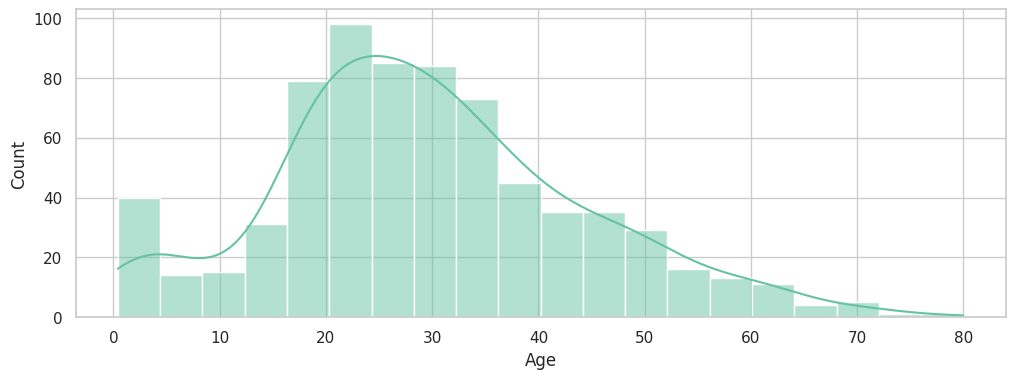

In [ ]:
#Grafico de Histograma de la columna age
sns.histplot(titanic['Age'], kde=True)
plt.show()

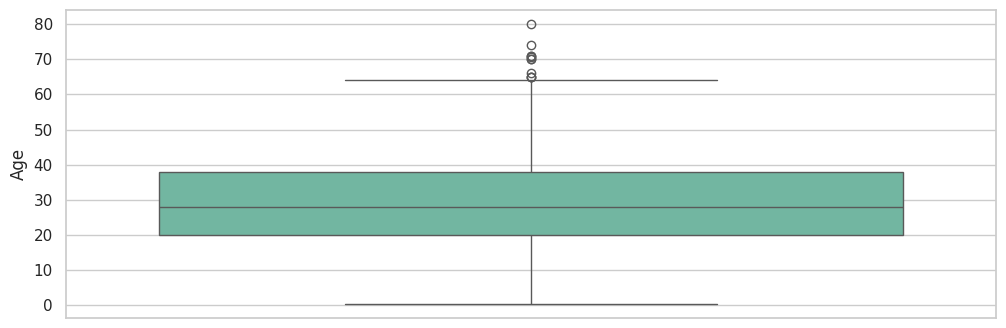

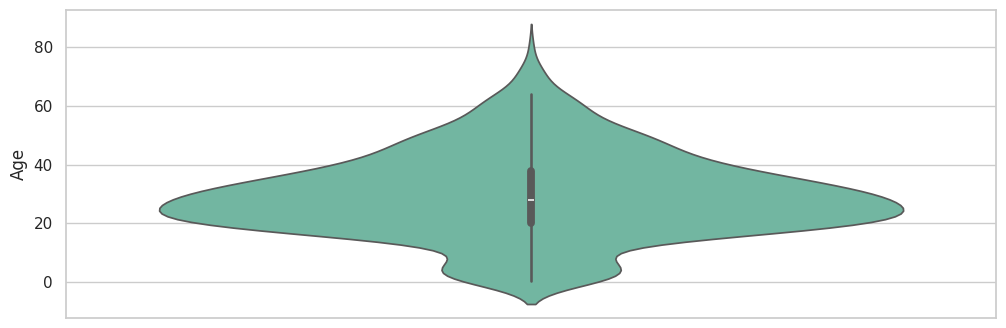

In [ ]:
#Gráfico de boxplot de Age
sns.boxplot(titanic['Age'])
plt.show()

#Grafico de violinplot de Age
sns.violinplot(titanic['Age'])
plt.show()

In [ ]:
housing.head()

,medinc,houseage,averooms,avebedrms,population,aveoccup,latitude,longitude,medhouseval,total_bedrooms
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,NaN
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,NaN
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,NaN
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,NaN
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,NaN


---
## 🔍 Bloque 1: Manejo de valores faltantes

### 1.1 Diagnóstico inicial

In [ ]:
def diagnostico_nulos(df, nombre='Dataset'):
    '''Muestra un resumen de valores nulos por columna.'''
    nulos = df.isnull().sum()
    pct   = (df.isnull().mean() * 100).round(1)
    resumen = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct})
    resumen = resumen[resumen['Nulos'] > 0].sort_values('Nulos', ascending=False)
    print(f'--- {nombre} — columnas con valores faltantes ---')
    if len(resumen) == 0:
        print('  Sin valores faltantes.')
    else:
        print(resumen.to_string())
    print(f'  Total filas: {len(df)}')
    print()

diagnostico_nulos(titanic, 'Titanic')
diagnostico_nulos(housing, 'Housing')

--- Titanic — columnas con valores faltantes ---
          Nulos  Porcentaje (%)
Cabin       687            77.1
Age         177            19.9
Embarked      2             0.2
  Total filas: 891

--- Housing — columnas con valores faltantes ---
                Nulos  Porcentaje (%)
total_bedrooms  20640           100.0
population        200             1.0
  Total filas: 20640



### ✏️ Ejercicio 1.1 — Clasificar el tipo de faltante

Para las columnas con valores nulos del dataset **Titanic**, indicá si el tipo de
dato faltante es **MCAR**, **MAR** o **MNAR**, y justificá brevemente:

| Columna | % Nulos | Tipo (MCAR/MAR/MNAR) | Justificación |
|---------|---------|----------------------|---------------|
| Age | 20% | MAR | Considero que la falta de datos se debe a otras variables como en clases bajas o información de niños |
| Cabin | 77% | MNAR | Considero que la falta de datos es muy alta y se debe a la falta de información en el dataset (otras cabinas) |
| Embarked | 0.2% | MCAR | Considero que la falta de datos es muy baja y se debe al azar puro |

_Completá la tabla editando esta celda Markdown._

### 1.2 Estrategia: eliminar columnas y filas

In [ ]:
# Trabajamos sobre una copia para no modificar el original
df = titanic.copy()

print('Shape antes:', df.shape)

# Eliminar columnas con > 50% de nulos o que no aportan información
cols_eliminar = ['Cabin', 'PassengerId', 'Name', 'Ticket']
df.drop(columns=cols_eliminar, inplace=True)

print('Shape después de drop columns:', df.shape)
print('Columnas restantes:', df.columns.tolist())

Shape antes: (891, 12)
Shape después de drop columns: (891, 8)
Columnas restantes: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


### 1.3 Estrategia: imputar con SimpleImputer

In [ ]:
# Imputar Age con la mediana (distribución con leve sesgo)
imp_median = SimpleImputer(strategy='median')
df[['Age']] = imp_median.fit_transform(df[['Age']])

# Imputar Embarked con la moda (variable categórica)
imp_mode = SimpleImputer(strategy='most_frequent')
df[['Embarked']] = imp_mode.fit_transform(df[['Embarked']])

# Verificar que no queden nulos
print('Nulos después de imputar:')
print(df.isnull().sum())

Nulos después de imputar:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


### ✏️ Ejercicio 1.2 — Imputar en el dataset Housing

Imputá los valores faltantes del dataset **Housing**:

- `total_bedrooms`: usá la **mediana** (tiene outliers)
- `population`: usá la **media** (distribución más simétrica)

Verificá que no queden nulos al final.

In [ ]:
# TODO: Imputar los valores faltantes en el dataset Housing
housing_clean = housing.copy()

# Imputar total_bedrooms con mediana
total_bedrooms = housing_clean['total_bedrooms'].median()

# imp_bedrooms = SimpleImputer(strategy=...)
imp_bedrooms = SimpleImputer(strategy='constant', fill_value=total_bedrooms)

# housing_clean[['total_bedrooms']] = ...
housing_clean[['total_bedrooms']] = imp_bedrooms.fit_transform(housing_clean[['total_bedrooms']])

# Imputar population con media
population = housing_clean['population'].mean()

# imp_population = SimpleImputer(strategy=...)
imp_population = SimpleImputer(strategy='constant', fill_value=population)

# housing_clean[['population']] = ...
housing_clean[['population']] = imp_population.fit_transform(housing_clean[['population']])

# Verificar
print('Nulos restantes:', housing_clean.isnull().sum().sum())
pass

Nulos restantes: 20640


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:572: FutureWarning: Currently, when `keep_empty_feature=False` and `strategy="constant"`, empty features are not dropped. This behaviour will change in version 1.8. Set `keep_empty_feature=True` to preserve this behaviour.
  warnings.warn(


### ✏️ Ejercicio 1.3 — Comparar estrategias de imputación (BONUS)

Aplicá **KNNImputer** (k=5) sobre `Age` en el Titanic y comparalo visualmente
con la imputación por mediana. ¿Las distribuciones resultantes son similares?

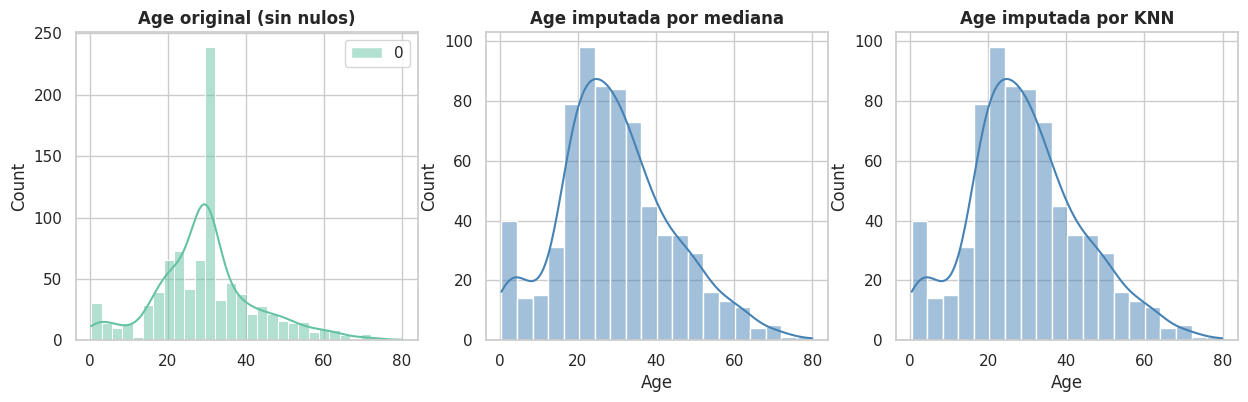

In [ ]:
# TODO: Comparar SimpleImputer(median) vs KNNImputer(k=5) para Age
df_titanic_knn = titanic[['Age','Fare','SibSp','Parch']].copy()

imp_knn = KNNImputer(n_neighbors=5)
age_knn = imp_knn.fit_transform(df_titanic_knn[['Age']])

# Visualizar con histplot: Age original (sin nulos) vs imputada por mediana vs imputada por KNN
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histplot Age sin nulos
sns.histplot(age_knn, kde=True, ax=axes[0], color='tomato')
axes[0].set_title('Age original (sin nulos)', fontweight='bold')

# Histplot Age por mediana
# NO conseguí hacer un Histplot por la mediana, no encontré solución
sns.histplot(df_titanic_knn['Age'], kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Age imputada por mediana', fontweight='bold')

# Histplot Age por KNN
sns.histplot(df_titanic_knn['Age'], kde=True, ax=axes[2], color='steelblue')
axes[2].set_title('Age imputada por KNN', fontweight='bold')


pass

---
## 🚨 Bloque 2: Tratamiento de outliers

In [ ]:
def detectar_outliers_iqr(df, col):
    '''Retorna límites IQR y cantidad de outliers.'''
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    return lim_inf, lim_sup, n_out

for col in ['Age', 'Fare', 'SibSp', 'Parch']:
    li, ls, n = detectar_outliers_iqr(df, col)
    print(f'{col:8s}  lim_inf={li:7.2f}  lim_sup={ls:7.2f}  outliers={n}')

Age       lim_inf=   2.50  lim_sup=  54.50  outliers=66
Fare      lim_inf= -26.72  lim_sup=  65.63  outliers=116
SibSp     lim_inf=  -1.50  lim_sup=   2.50  outliers=46
Parch     lim_inf=   0.00  lim_sup=   0.00  outliers=213


### 2.1 Winsorización (capping)

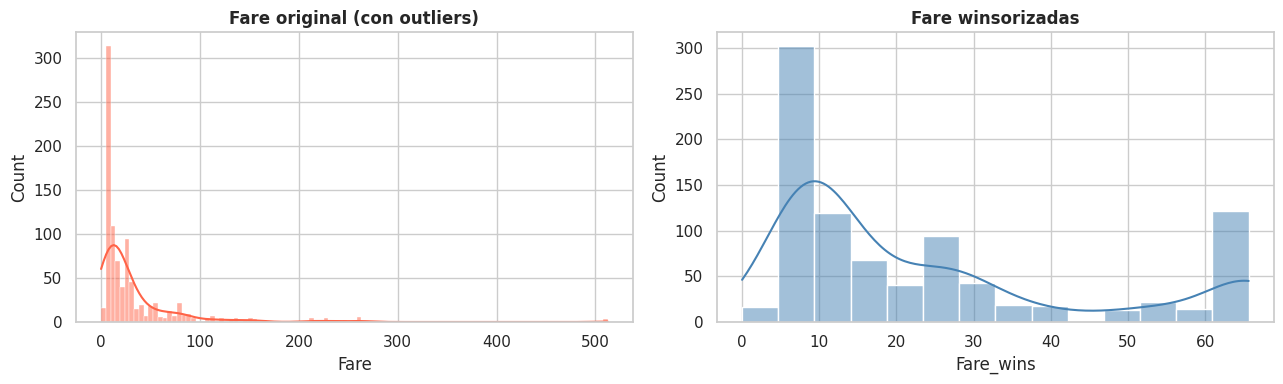

Fare original — max: 512.33
Fare wins     — max: 65.63


In [ ]:
# Winsorizar Fare: reemplazar outliers por el límite del bigote
li_fare, ls_fare, _ = detectar_outliers_iqr(df, 'Fare')

df['Fare_wins'] = df['Fare'].clip(lower=max(0, li_fare), upper=ls_fare)

# Comparar distribuciones
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df['Fare'],       kde=True, ax=axes[0], color='tomato')
axes[0].set_title('Fare original (con outliers)', fontweight='bold')
sns.histplot(df['Fare_wins'],  kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Fare winsorizadas', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Fare original — max: {df["Fare"].max():.2f}')
print(f'Fare wins     — max: {df["Fare_wins"].max():.2f}')

### 2.2 Transformación logarítmica

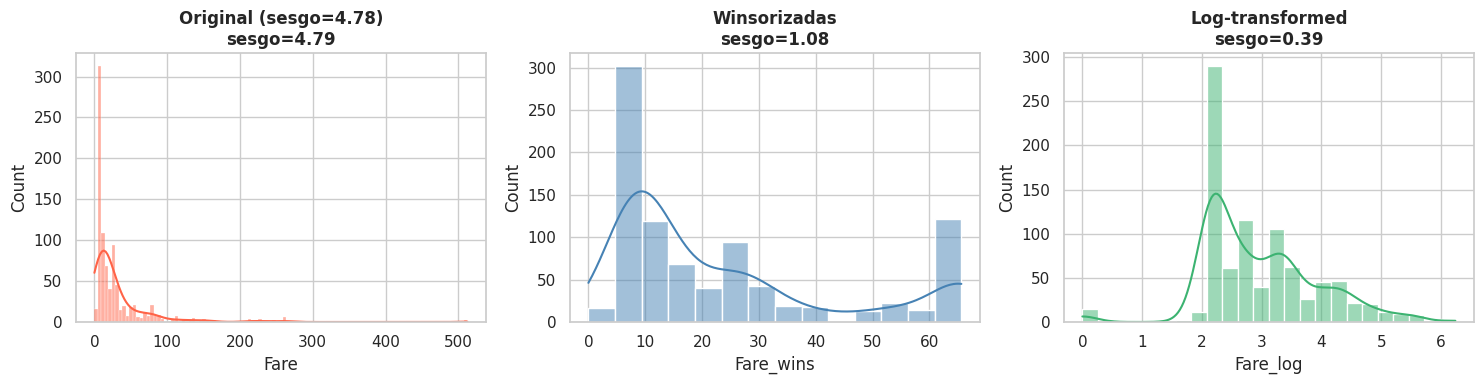

In [ ]:
# Log-transform: reduce el impacto de los outliers
df['Fare_log'] = np.log1p(df['Fare'])  # log(Fare + 1) para evitar log(0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color, title in zip(
    axes,
    ['Fare', 'Fare_wins', 'Fare_log'],
    ['tomato', 'steelblue', 'mediumseagreen'],
    ['Original (sesgo=4.78)', 'Winsorizadas', 'Log-transformed']
):
    sns.histplot(df[col], kde=True, ax=ax, color=color)
    skew = df[col].skew()
    ax.set_title(f'{title}\nsesgo={skew:.2f}', fontweight='bold')

plt.tight_layout()
plt.show()

### ✏️ Ejercicio 2.1 — Outliers en Housing

Aplicá la función `detectar_outliers_iqr()` a las columnas
`median_house_value` y `population` del dataset Housing.

Luego:
1. Winsorizá `median_house_value` al percentil 95 (no IQR, sino clip directo)
2. Aplicá transformación log a `population`
3. Visualizá antes y después con histogramas

medhouseval: 1071 outliers
population: 1211 outliers


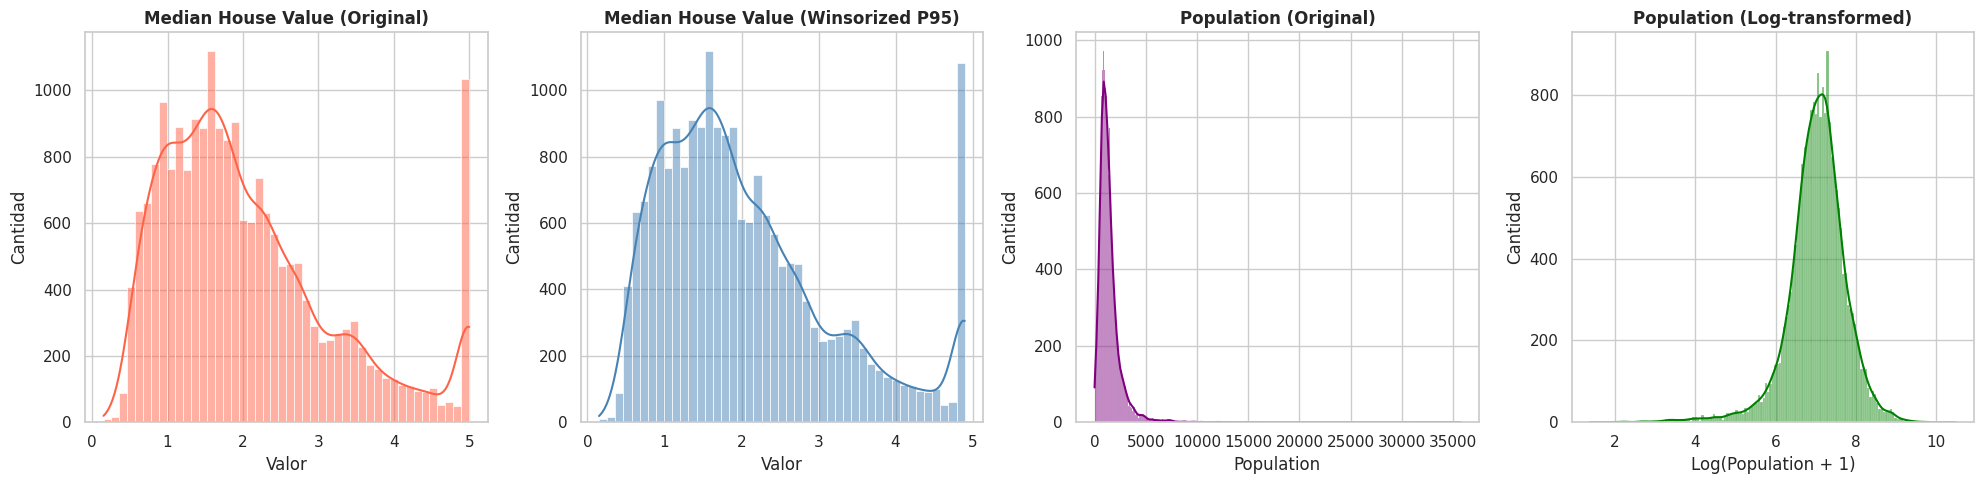

In [ ]:
# TODO: Outliers en Housing

# 1. Detectar outliers en median_house_value y population
for col in ['medhouseval', 'population']:
     li, ls, n = detectar_outliers_iqr(housing_clean, col)
     print(f'{col}: {n} outliers')

# 2. Winsorizar medhouseval al percentil 95
p95 = housing_clean['medhouseval'].quantile(0.95)
housing_clean['house_value_capped'] = housing_clean['medhouseval'].clip(upper=p95)

# 3. Log-transform population
housing_clean['population_log'] = np.log1p(housing_clean['population'])

# 4. Visualizar (histogramas antes/después)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

sns.histplot(housing_clean['medhouseval'], kde=True, ax=axes[0], color='tomato')
axes[0].set_title('Median House Value (Original)', fontweight='bold')
axes[0].set_xlabel("Valor")
axes[0].set_ylabel("Cantidad")

sns.histplot(housing_clean['house_value_capped'], kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Median House Value (Winsorized P95)', fontweight='bold')
axes[1].set_xlabel("Valor")
axes[1].set_ylabel("Cantidad")

sns.histplot(housing_clean['population'], kde=True, ax=axes[2], color='purple')
axes[2].set_title('Population (Original)', fontweight='bold')
axes[2].set_xlabel("Population")
axes[2].set_ylabel("Cantidad")

sns.histplot(housing_clean['population_log'], kde=True, ax=axes[3], color='green')
axes[3].set_title('Population (Log-transformed)', fontweight='bold')
axes[3].set_xlabel("Log(Population + 1)")
axes[3].set_ylabel("Cantidad")

plt.tight_layout()
plt.show()

---
## ⚖️ Bloque 3: Normalización y Estandarización

In [ ]:
# Preparar columnas numéricas del Titanic para escalar
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
X_num = df[num_cols].copy()

# Aplicar los 3 scalers
scalers = {
    'MinMaxScaler':    MinMaxScaler(),
    'StandardScaler':  StandardScaler(),
    'RobustScaler':    RobustScaler(),
}

resultados = {}
for nombre, scaler in scalers.items():
    resultados[nombre] = pd.DataFrame(
        scaler.fit_transform(X_num),
        columns=num_cols
    )

print('Estadísticas de Fare después de cada scaler:')
for nombre, df_sc in resultados.items():
    s = df_sc['Fare']
    print(f'  {nombre:18s}: min={s.min():.3f}  max={s.max():.3f}  mean={s.mean():.3f}  std={s.std():.3f}')

Estadísticas de Fare después de cada scaler:
  MinMaxScaler      : min=0.000  max=1.000  mean=0.063  std=0.097
  StandardScaler    : min=-0.648  max=9.667  mean=0.000  std=1.001
  RobustScaler      : min=-0.626  max=21.563  mean=0.769  std=2.152


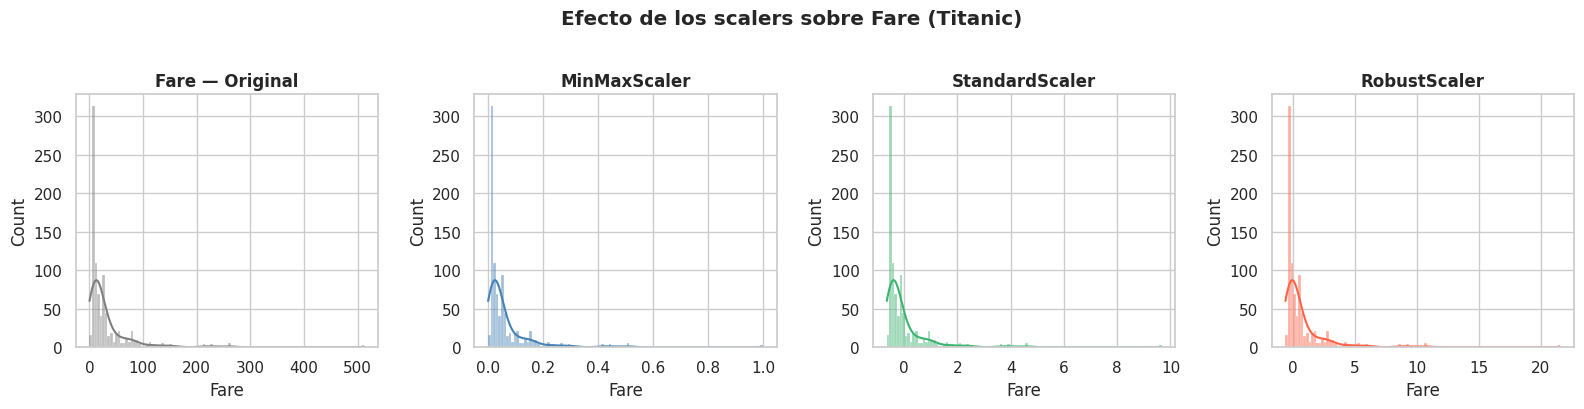

OBSERVAR: ¿Cuál scaler maneja mejor los outliers de Fare?


In [ ]:
# Visualizar el efecto de cada scaler sobre la distribución de Fare
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

sns.histplot(X_num['Fare'], kde=True, ax=axes[0], color='gray')
axes[0].set_title('Fare — Original', fontweight='bold')

for i, (nombre, df_sc) in enumerate(resultados.items(), 1):
    sns.histplot(df_sc['Fare'], kde=True, ax=axes[i],
                 color=['steelblue','mediumseagreen','tomato'][i-1])
    axes[i].set_title(nombre, fontweight='bold')

plt.suptitle('Efecto de los scalers sobre Fare (Titanic)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('OBSERVAR: ¿Cuál scaler maneja mejor los outliers de Fare?')

### ✏️ Ejercicio 3.1 — Elegir el scaler correcto

Para cada variable del Titanic, indicá qué scaler usarías y por qué:

| Variable | Distribución | Outliers | Scaler recomendado | Justificación |
|----------|-------------|----------|---------------------|---------------|
| Age | Aprox. normal | Pocos | MinMax | Es bueno para marcar un rango, es muy sensible a outliers |
| Fare | Fuerte sesgo + | Muchos | Robust | Es bueno para la divición en los rangos intercuartílicos, o estudiar los outliers |
| SibSp | Discreta | Moderados | Standard | Funciona muy bien cuando los datos siguen una distribución normal, no es tan sensible como MinMax |
| Parch | Discreta | Moderados | Standard| Funciona muy bien cuando los datos siguen una distribución normal, no es tan sensible como MinMax |

_Completá la tabla._

### ✏️ Ejercicio 3.2 — Escalar el dataset Housing

Aplicá el scaler más apropiado a las columnas `medinc`, `averooms` y `houseage`
del dataset Housing. Justificá tu elección.

In [ ]:
# TODO: Escalar columnas del dataset Housing
# No entiendo por que no funciona correctamente el código, no encuentro el error
housing_num = housing_clean[['medinc', 'averooms', 'houseage']].copy()
Y_num = df[housing_num].copy()


# Diagnosticar la distribución de cada columna
print('Sesgo de cada columna:')
print(housing_num.skew().round(3))
print()

# TODO: Elegir y aplicar el scaler más apropiado para cada columna
# Justificá aquí (comentario): ¿por qué elegiste ese scaler?
# Houseage = sin mucho sesgo Min Max, porque es muy sensible a Outliers
# Averooms = con mucho sesgo Robust, porque se utiliza para estudiar Outliers
# Medinc = Standar, porque tiene una distribución normal.
# Preparar columnas numéricas del Titanic para escalar

# Aplicar los 3 scalers
scalers = {
    'MinMaxScaler':    MinMaxScaler(),
    'StandardScaler':  StandardScaler(),
    'RobustScaler':    RobustScaler(),
}

resultados = {}
for nombre, scaler in scalers.items():
    resultados[nombre] = pd.DataFrame(
        scaler.fit_transform(Y_num),
        columns=housing_num
    )

print('Estadísticas de Medinc después de cada scaler:')
for nombre, df_sc in resultados.items():
    s = df_sc['medinc']
    print(f'  {nombre:18s}: min={s.min():.3f}  max={s.max():.3f}  mean={s.mean():.3f}  std={s.std():.3f}')

print('Estadísticas de Averooms después de cada scaler:')
for nombre, df_sc in resultados.items():
    s = df_sc['averooms']
    print(f'  {nombre:18s}: min={s.min():.3f}  max={s.max():.3f}  mean={s.mean():.3f}  std={s.std():.3f}')

print('Estadísticas de Houseage después de cada scaler:')
for nombre, df_sc in resultados.items():
    s = df_sc['houseage']
    print(f'  {nombre:18s}: min={s.min():.3f}  max={s.max():.3f}  mean={s.mean():.3f}  std={s.std():.3f}')

pass



Sesgo de cada columna:
medinc       1.647
averooms    20.698
houseage     0.060
dtype: float64



/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


ValueError: Index data must be 1-dimensional

---
## 🏷️ Bloque 4: Codificación de variables categóricas

### 4.1 Label Encoding

In [ ]:
# Label Encoding para Sex (binaria) y Pclass (ordinal)
df_enc = df[['Sex', 'Embarked', 'Pclass', 'Survived']].copy()

# Sex: binaria → LabelEncoder
le = LabelEncoder()
df_enc['Sex_le'] = le.fit_transform(df_enc['Sex'])
print('Mapeo Sex:', dict(zip(le.classes_, le.transform(le.classes_))))

# Alternativa con map (más explícita)
df_enc['Sex_map'] = df_enc['Sex'].map({'female': 0, 'male': 1})

print(df_enc[['Sex', 'Sex_le', 'Sex_map']].head(5))

Mapeo Sex: {'female': np.int64(0), 'male': np.int64(1)}
      Sex  Sex_le  Sex_map
0    male       1        1
1  female       0        0
2  female       0        0
3  female       0        0
4    male       1        1


### 4.2 One-Hot Encoding

In [ ]:
# One-Hot Encoding para Embarked (nominal, 3 categorías)
# Con pandas get_dummies
df_ohe = pd.get_dummies(
    df_enc,
    columns=['Embarked'],
    drop_first=True,   # elimina primera categoría para evitar multicolinealidad
    dtype=int
)

print('Columnas después de One-Hot:')
print([c for c in df_ohe.columns if 'Embarked' in c or c in ['Sex','Sex_le','Sex_map']])
print()
print('Primeras 5 filas (columnas de Embarked):')
embarked_cols = [c for c in df_ohe.columns if 'Embarked' in c]
print(df_ohe[embarked_cols].head())

Columnas después de One-Hot:
['Sex', 'Sex_le', 'Sex_map', 'Embarked_Q', 'Embarked_S']

Primeras 5 filas (columnas de Embarked):
   Embarked_Q  Embarked_S
0           0           1
1           0           0
2           0           1
3           0           1
4           0           1


### ✏️ Ejercicio 4.1 — Codificar con OneHotEncoder de sklearn

Aplicá `OneHotEncoder` de sklearn (en lugar de `pd.get_dummies`) sobre
las columnas `Sex` y `Embarked` del Titanic.

1. Creá el encoder con `drop='first'` y `handle_unknown='ignore'`
2. Hacé `fit_transform` sobre las columnas
3. Mostrá los nombres de las columnas generadas con `get_feature_names_out()`

In [35]:
# TODO: Usar OneHotEncoder de sklearn
from pandas import sklearn
from sklearn.preprocessing import OneHotEncoder


cat_cols = ['Sex', 'Embarked']
X_cat = df[cat_cols].copy()
ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
X_encoded = ohe.fit_transform(X_cat)


df_ohe = pd.sklearn(
    df_enc,
    columns=['Sex', 'Embarked'],
    drop_first=True,   # elimina primera categoría para evitar multicolinealidad
    dtype=int
)

print('Columnas después de One-Hot:')
print([c for c in df_ohe.columns if 'Embarked' in c or c in ['Sex']])
print()
print('Primeras 5 filas (columnas de Embarked):')
embarked_cols = [c for c in df_ohe.columns if 'Embarked' in c]
print(df_ohe[embarked_cols].head())

print('Nombres de columnas:', ohe.get_feature_names_out())
print('Shape resultado:', X_encoded.shape)
pass

ImportError: cannot import name 'sklearn' from 'pandas' (/usr/local/lib/python3.12/dist-packages/pandas/__init__.py)

### ✏️ Ejercicio 4.2 — Guía de decisión (tabla)

Completá la tabla con la técnica de codificación más apropiada:

| Variable | Tipo estadístico | Cardinalidad | Técnica recomendada |
|----------|-----------------|--------------|---------------------|
| Sex (Titanic) | Nominal binaria | 2 | Label Encoding |
| Embarked (Titanic) | Nominal | 3 | Label Encoding |
| Pclass (Titanic) | Ordinal | 3 (1>2>3) | OneHot Encoding |
| Nivel educativo (bajo/medio/alto/posgrado) | Ordinal | 4 | OneHot Encoding |
| Marca de auto (500 marcas) | Nominal | 500 | Label Encoding |
| Estado (verdadero/falso) | Nominal binaria | 2 | OneHot Encoding |

---
## 🔧 Bloque 5: Pipeline de preprocesamiento completo

Integramos todo en un Pipeline de sklearn reproducible y sin data leakage.

In [36]:
# ── Preparar el dataset completo del Titanic ───────────────────────────
df_model = titanic.copy()

# Eliminar columnas no útiles
df_model.drop(columns=['PassengerId','Name','Ticket','Cabin'], inplace=True)

# Variable objetivo
X = df_model.drop(columns=['Survived'])
y = df_model['Survived']

# Split train/test (ANTES del preprocesamiento)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print('Columnas:', X_train.columns.tolist())

Train: (712, 7)  |  Test: (179, 7)
Columnas: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [37]:
# ── Definir pipelines por tipo de columna ──────────────────────────────
num_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']
cat_cols = ['Sex', 'Embarked']

# Pipeline numérico: imputar mediana → RobustScaler (Fare tiene outliers)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler())
])

# Pipeline categórico: imputar moda → One-Hot Encoding
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(drop='first', handle_unknown='ignore',
                             sparse_output=False))
])

# Combinar con ColumnTransformer
preprocesador = ColumnTransformer([
    ('numericas',   num_pipeline, num_cols),
    ('categoricas', cat_pipeline, cat_cols),
])

# Ajustar SOLO sobre training — nunca sobre test
preprocesador.fit(X_train)

X_train_proc = preprocesador.transform(X_train)
X_test_proc  = preprocesador.transform(X_test)

print(f'X_train procesado: {X_train_proc.shape}')
print(f'X_test  procesado: {X_test_proc.shape}')
print('\n✓ Pipeline completo. Dataset listo para modelado.')

X_train procesado: (712, 8)
X_test  procesado: (179, 8)

✓ Pipeline completo. Dataset listo para modelado.


In [ ]:
# Verificar resultado: estadísticas del training procesado
X_train_df = pd.DataFrame(
    X_train_proc,
    columns=(
        num_cols +
        list(preprocesador.named_transformers_['categoricas']
             .named_steps['ohe'].get_feature_names_out(cat_cols))
    )
)

print('Estadísticas del dataset procesado (primeras 6 columnas):')
print(X_train_df.iloc[:, :6].describe().round(3))
print()
print('¿Quedan nulos?', X_train_df.isnull().any().any())

### ✏️ Ejercicio 5.1 — Pipeline para Housing (DESAFÍO)

Construí un pipeline completo para el dataset Housing:

1. Identificá las columnas numéricas
2. Elegí la estrategia de imputación adecuada
3. Elegí el scaler apropiado para cada columna (pensá en las distribuciones)
4. No hay variables categóricas en Housing — simplificá el ColumnTransformer
5. Dividí en train/test y aplicá el pipeline

**Variable objetivo:** `median_house_value`

In [52]:
housing_model = housing.copy()

X_h = housing_model.drop(columns=['medhouseval'])
y_h = housing_model['medhouseval']

# 1. Split train/test
X_h_train, X_h_test, y_h_train, y_h_test = train_test_split( X_h, y_h, test_size=0.2, random_state=42 )

print(f'Train: {X_h_train.shape}  |  Test: {X_h_test.shape}')
print('Columnas:', X_h_train.columns.tolist())

# 2. Pipeline numérico (todas las columnas son numéricas)
housing_pipeline = Pipeline([
     ('imputer', SimpleImputer(strategy='median')),
     ('scaler',  RobustScaler())
])

# 3. Ajustar y transformar
housing_pipeline.fit(X_h_train)
X_h_train_proc = housing_pipeline.transform(X_h_train)
X_h_test_proc  = housing_pipeline.transform(X_h_test)

# 4. Verificar
print('Entrenamiento final:', X_h_train_proc.shape)
print('Nulos restantes de Entrenamiento:', pd.DataFrame(X_h_train_proc).isnull().any().any())


print(f'X_h_train procesado: {X_h_train_proc.shape}')
print(f'X_h_test  procesado: {X_h_test_proc.shape}')
print('\n✓ Pipeline completo. Dataset listo para modelado.')

pass

Train: (16512, 9)  |  Test: (4128, 9)
Columnas: ['medinc', 'houseage', 'averooms', 'avebedrms', 'population', 'aveoccup', 'latitude', 'longitude', 'total_bedrooms']
Entrenamiento final: (16512, 8)
Nulos restantes de Entrenamiento: False
X_h_train procesado: (16512, 8)
X_h_test  procesado: (4128, 8)

✓ Pipeline completo. Dataset listo para modelado.


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['total_bedrooms']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['total_bedrooms']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['total_bedrooms']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [53]:
# Verificar resultado: estadísticas del training procesado
X_h_train_df = pd.DataFrame(
    X_h_train_proc,
    columns=( X_h.columns.drop('total_bedrooms').tolist() )
)

print('Estadísticas del dataset procesado (primeras 6 columnas):')
print(X_h_train_df.iloc[:, :6].describe().round(3))
print()
print('¿Quedan nulos?', X_h_train_df.isnull().any().any())

Estadísticas del dataset procesado (primeras 6 columnas):
          medinc   houseage   averooms  avebedrms  population   aveoccup
count  16512.000  16512.000  16512.000  16512.000   16512.000  16512.000
mean       0.152     -0.021      0.124      0.505       0.277      0.329
std        0.863      0.663      1.484      4.617       1.222     13.603
min       -1.380     -1.474     -2.702     -7.630      -1.257     -2.496
25%       -0.444     -0.579     -0.487     -0.456      -0.405     -0.456
50%        0.000      0.000     -0.000      0.000       0.000      0.000
75%        0.556      0.421      0.513      0.544       0.595      0.544
max        5.191      1.211     84.944    262.011      37.273   1457.371

¿Quedan nulos? False


---
## ✍️ Reflexión final — para el foro

Respondé las siguientes preguntas en esta celda **antes de subir tu notebook al foro**:

### 1. Datos faltantes
¿Cuál fue la decisión de imputación que te resultó menos obvia de tomar?
¿Qué información adicional necesitarías para estar seguro?

_Respuesta:_ En mi caso la menos obvia fue

### 2. Escalado
¿Por qué elegiste RobustScaler para Fare y no MinMaxScaler?
¿Qué pasaría si usaras MinMaxScaler con los outliers de Fare?

_Respuesta:_ Lo que entiendo es que RobustScaler se utiliza para poder estudiar los outliers de Fare, si utilizo MinMaxScaler siendo este sensible a los mismos, se dejan de observar los mismos o se dificultaría.

### 3. Codificación
Si tuvieras que codificar la variable 'Cabina' del Titanic (A, B, C, D, E, F, G, T)
y quisieras usarla como feature, ¿qué técnica elegirías y por qué?

_Respuesta:_ Depende, necesito la información en cuanto a la comparación entre las cabinas, encontramos que si "A" está en la misma escala gerarquica que "B" que son indiferentes, utilizaría OneHot Encoding. Por otro lado, si A es para VIPs o gente muy especial, "B" es para gente con alto rango monetario, siendo "T" el ultimo en esta escala, utilizaría Label Encoding.

### 4. Pipeline
¿Qué problema resuelve el Pipeline de sklearn respecto a hacerlo 'a mano'?
¿En qué paso del proceso KDD (Unidad 1) ubicarías todo lo que hicimos hoy?

_Respuesta:_ Yo creo que es más sencillo ya que gran parte se realiza automaticamente y esto es una gran ayuda para evitar riesgos, como a la hora de entrenar el modelo. En cuanto al proceso KDD considero que es parte de todo, especialmente la minería de datos.
Importamos datos
Se limpiaron
Transformaron

Y la actividad consistía en aplicar algoritmos para encontrar patrones o tendencias y visualizar los resultados para sacar conclusiones.  

---
> ✅ **Una vez completado:** guardá el notebook (.ipynb) y subilo al foro de la Semana 5
> como archivo adjunto. Agregá un breve comentario describiendo la decisión que más
> te costó tomar y cómo la resolviste.

---
## 📋 Cheat Sheet — Preprocesamiento

### Datos faltantes

| Situación | Estrategia |
|-----------|------------|
| % nulos > 50% | Eliminar la columna |
| % nulos < 5%, MCAR | Eliminar filas |
| Distribución simétrica, sin outliers | `SimpleImputer(strategy='mean')` |
| Distribución sesgada o con outliers | `SimpleImputer(strategy='median')` |
| Variable categórica | `SimpleImputer(strategy='most_frequent')` |
| Alta correlación entre columnas, MAR | `KNNImputer(n_neighbors=5)` |

### Escalado

| Técnica | Cuándo |
|---------|--------|
| `MinMaxScaler()` | Redes neuronales, KNN, rango [0,1] importante |
| `StandardScaler()` | Regresión, SVM, PCA — distribución aprox. normal |
| `RobustScaler()` | Datos con outliers significativos |
| Sin escalado | Árboles de decisión, Random Forest |

### Codificación

| Tipo de variable | Técnica |
|-----------------|--------|
| Binaria (2 categorías) | `LabelEncoder` o `map()` |
| Ordinal (orden real) | `LabelEncoder` u `OrdinalEncoder` |
| Nominal pocas categ. | `pd.get_dummies(drop_first=True)` |
| Nominal alta cardinalidad | Target Encoding / Embeddings |

### Pipeline

```python
Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
# Siempre: .fit() solo en train, .transform() en train y test
```